# UV Index regresison - Model Training
### Metrics: MAE, RSME, R2
### Models: Linear regression (baseline) -> Random forest -> XGBoost -> LightGBM -> LSTM
### Split: Temporal - train 2020-2024, test: 2026

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE: {DEVICE}")


DEVICE: cuda


# 1. Load & Prepare Data

In [2]:
DATA_DIR = Path('../..') / 'data' / 'processed' / 'features'
df = pd.read_csv(DATA_DIR / 'features_regression.csv', parse_dates=['timestamp'])
print(f"shape: {df.shape}")
print(f'Date range: {df["timestamp"].min()} -> {df["timestamp"].max()}')


shape: (386992, 38)
Date range: 2015-06-23 07:00:00 -> 2026-04-21 23:00:00


In [3]:
TARGET = 'uv_index'
DROP_COLS = ['timestamp', 'location_id', 'solar_angle_category', 'uv_source']

UV_LAG_COLS = [c for c in df.columns if c.startswith('uv_lag') or c.startswith('uv_rolling')
               or c in ['uv_diff_1h', 'uv_max_today_so_far']]

LEAKAGE_COLS = ['shortwave_radiation', 'direct_radiation', 'diffuse_radiation',
                'clearness_index', 'solar_efficiency', 'radiation_ratio',
                'temp_radiation_ratio', 'uv_clear_sky_ratio']

# ── 14 Correlation-filtered features (từ comparison.md) ──────────────────────
# Loại bỏ 23 features dư thừa do đa cộng tuyến (|r| > 0.85 lẫn nhau).
# Giữ lại đại diện tốt nhất từ mỗi nhóm correlated features:
FILTERED_14_COLS = [
    # Solar geometry (đại diện thay cho: hour, hour_sin, solar_elevation, solar_zenith, air_mass, ...)
    'cos_solar_zenith',        # |r|=0.725 với UV - đại diện nhóm solar geometry
    'hour_cos',                # |r|=0.701 - đại diện diurnal cycle
    'doy_sin',                 # |r|=0.202 - đại diện seasonal cycle
    # Nhiệt & Ẩm (đại diện thay cho: heat_index, heat_index_anomaly)
    'temperature_2m',          # |r|=0.539
    'relative_humidity_2m',    # |r|=0.504
    # Mây (phân biệt mây thấp vs mây ti)
    'cloud_cover',             # |r|=0.272 - tổng lượng mây
    'cloud_cover_high',        # |r|=0.286 - mây ti (ảnh hưởng UV khác mây thấp)
    'solar_cloud_interaction', # |r|=0.554 - interaction feature, r cao nhất nhóm derived
    # Khí quyển
    'ozone_anomaly',           # |r|=0.323 - yếu tố vật lý UV quan trọng
    'aerosol_optical_depth',   # |r|=0.063 - tải aerosol
    'pm2_5',                   # |r|=0.132 - chất lượng không khí
    # Thời tiết chung
    'pressure_msl',            # |r|=0.192 - proxy hệ thống thời tiết
    'precipitation',           # |r|=0.067 - mưa, suy giảm UV phi tuyến
    'wind_speed_10m',          # |r|=0.117 - proxy phân tán aerosol
]

# Kiểm tra tất cả features có tồn tại không
FEATURE_COLS = [c for c in FILTERED_14_COLS if c in df.columns]
missing_filtered = [c for c in FILTERED_14_COLS if c not in df.columns]
if missing_filtered:
    print(f"⚠️ Warning: {len(missing_filtered)} filtered features missing: {missing_filtered}")

print(f"✅ Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"   (Reduced from {len([c for c in df.columns if c not in DROP_COLS + [TARGET] + UV_LAG_COLS + LEAKAGE_COLS])} → {len(FEATURE_COLS)} features)")
print()
print(f"Excluded UV lag features ({len(UV_LAG_COLS)}): {UV_LAG_COLS}")
print()
miss = df[FEATURE_COLS].isnull().mean().sort_values(ascending=False)
print("Missing per feature:")
print(miss[miss > 0].to_string() if (miss > 0).any() else 'No Missing value')


⚠️ Warning: 4 filtered features missing: ['cloud_cover_high', 'aerosol_optical_depth', 'pm2_5', 'precipitation']
✅ Features (10): ['cos_solar_zenith', 'hour_cos', 'doy_sin', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'solar_cloud_interaction', 'ozone_anomaly', 'pressure_msl', 'wind_speed_10m']
   (Reduced from 34 → 10 features)

Excluded UV lag features (0): []

Missing per feature:
No Missing value


Filtered to real UV data: 386992 rows
WeatherBit: 380811 rows
Open_Meteo: 6181 rows
Date range: 2015-06-23 07:00:00 -> 2026-04-21 23:00:00


train: 270881, val: 58677, test: 57434


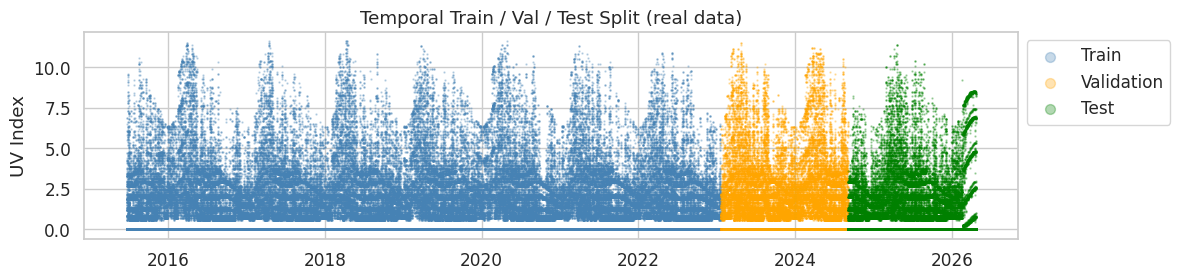

In [4]:
if 'uv_source' in df.columns:
    real_mask = df['uv_source'].isin(['weatherbit', 'open_meteo']) & df['uv_index'].notna()
    df = df[real_mask].copy()
    print(f'Filtered to real UV data: {len(df)} rows')
    print(f'WeatherBit: {(df["uv_source"] == "weatherbit").sum()} rows')
    print(f'Open_Meteo: {(df["uv_source"] == "open_meteo").sum()} rows')
    print(f'Date range: {df["timestamp"].min()} -> {df["timestamp"].max()}')

from datetime import timedelta
min_date = df['timestamp'].min()
max_date = df['timestamp'].max()
total_days = (max_date - min_date).days

train_days = int(total_days * 0.70)
val_days = int(total_days * 0.15)

train_end = min_date + timedelta(days=train_days)
val_end = train_end + timedelta(days=val_days)

train = df[(df['timestamp'] >= min_date) & (df['timestamp'] <  train_end)].copy()
val = df[(df['timestamp'] >= train_end) & (df['timestamp'] < val_end)].copy()
test = df[df['timestamp'] >= val_end].copy()

print(f"train: {len(train)}, val: {len(val)}, test: {len(test)}")

fig, ax = plt.subplots(figsize=(12, 3))
for split, color, label in [(train, 'steelblue', 'Train'), (val, 'orange', 'Validation'), (test, 'green', 'Test')]:
    ax.scatter(split['timestamp'], split[TARGET], s=0.5, alpha=0.3, c=color, label=label)
ax.set_ylabel("UV Index")
ax.set_title("Temporal Train / Val / Test Split (real data)")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), markerscale=10)
plt.tight_layout()
plt.show()

In [5]:
fill_values = train[FEATURE_COLS].median()
y_train = train[TARGET].values
y_val = val[TARGET].values
y_test = test[TARGET].values

X_train = train[FEATURE_COLS].values
X_val = val[FEATURE_COLS].values
X_test = test[FEATURE_COLS].values

X_train_filled = train[FEATURE_COLS].fillna(fill_values).values
X_val_filled = val[FEATURE_COLS].fillna(fill_values).values
X_test_filled = test[FEATURE_COLS].fillna(fill_values).values

scaler_X = StandardScaler().fit(X_train_filled)
X_train_s = scaler_X.transform(X_train_filled)
X_val_s = scaler_X.transform(X_val_filled)
X_test_s = scaler_X.transform(X_test_filled)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val: {X_val.shape}, y_val: {y_val.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')
print(f'NaN kept for tree models, median-filled for Linear/LSTM')

X_train: (270881, 10), y_train: (270881,)
X_val: (58677, 10), y_val: (58677,)
X_test: (57434, 10), y_test: (57434,)
NaN kept for tree models, median-filled for Linear/LSTM


# 2.Evaluation Helpers

In [6]:
results = {}
def evaluate(name, y_true, y_pred, split='val'):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 0.1 ))) * 100
    results[f'{name}_{split}'] =  {'MAE': mae, 'RMSE': rmse,'R2': r2, 'MAPE': mape}
    print(f'{name}_{split} MAE: {mae:.4f} RMSE: {rmse:.4f} R2: {r2} MAPE: {mape} ')
    return mae, rmse, r2, mape

def plot_predictions(y_true, y_pred, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.1, s=4)
    lims = [0, max(y_true.max(), y_pred.max()) + 0.5]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel("Actual UV Index")
    ax.set_ylabel("Predicted UV Index")
    ax.set_title(title)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    return ax

# 3. Baseline - Linear Regression

In [7]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
pred_lr_train = lr.predict(X_train_s)
pred_lr_val = lr.predict(X_val_s)
pred_lr_test = lr.predict(X_test_s)

evaluate("LinearRegression", y_train, pred_lr_train, 'train')
evaluate("LinearRegression", y_val, pred_lr_val, 'val')
evaluate("LinearRegression", y_test, pred_lr_test, 'test')

LinearRegression_train MAE: 0.5597 RMSE: 0.8156 R2: 0.7934970694218718 MAPE: 244.67562994230119 
LinearRegression_val MAE: 0.6227 RMSE: 0.9712 R2: 0.7568660712991843 MAPE: 244.05859087816458 
LinearRegression_test MAE: 0.6121 RMSE: 0.8798 R2: 0.7462144052150492 MAPE: 264.0294831551544 


(0.6120870809629612,
 np.float64(0.879803574406205),
 0.7462144052150492,
 np.float64(264.0294831551544))

# 3.5 Decision Tree

In [8]:
dt = DecisionTreeRegressor(max_depth=12, min_samples_split=20, random_state=SEED)
dt.fit(X_train_filled, y_train)
pred_dt_train = dt.predict(X_train_filled)
pred_dt_val = dt.predict(X_val_filled)
pred_dt_test = dt.predict(X_test_filled)
evaluate("DecisionTree", y_train, pred_dt_train, 'train')
evaluate("DecisionTree", y_val, pred_dt_val, 'val')
evaluate("DecisionTree", y_test, pred_dt_test, 'test')

DecisionTree_train MAE: 0.1911 RMSE: 0.4790 R2: 0.9287734910129388 MAPE: 7.5262698439534175 
DecisionTree_val MAE: 0.3177 RMSE: 0.7650 R2: 0.8491442813811956 MAPE: 14.427489556540696 
DecisionTree_test MAE: 0.2875 RMSE: 0.6976 R2: 0.8404400050948638 MAPE: 22.044805405808056 


(0.2874990919095191,
 np.float64(0.697612486347377),
 0.8404400050948638,
 np.float64(22.044805405808056))

# 4. Random Forest

In [9]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features='sqrt',
    n_jobs=-1,
    random_state=SEED
)

rf.fit(X_train, y_train)
pred_rf_train = rf.predict(X_train)
pred_rf_val = rf.predict(X_val)
pred_rf_test = rf.predict(X_test)
evaluate("RandomForest", y_train, pred_rf_train, 'train')
evaluate('RandomForest', y_val, pred_rf_val, 'val')
evaluate('RandomForest', y_test, pred_rf_test, 'test')

RandomForest_train MAE: 0.2069 RMSE: 0.4845 R2: 0.9271285513904317 MAPE: 14.36469803580091 
RandomForest_val MAE: 0.3037 RMSE: 0.6948 R2: 0.8755539178354651 MAPE: 23.450050414990674 
RandomForest_test MAE: 0.2683 RMSE: 0.6171 R2: 0.8751336000470857 MAPE: 28.98267433442084 


(0.26831297164837753,
 np.float64(0.6171276906616325),
 0.8751336000470857,
 np.float64(28.98267433442084))

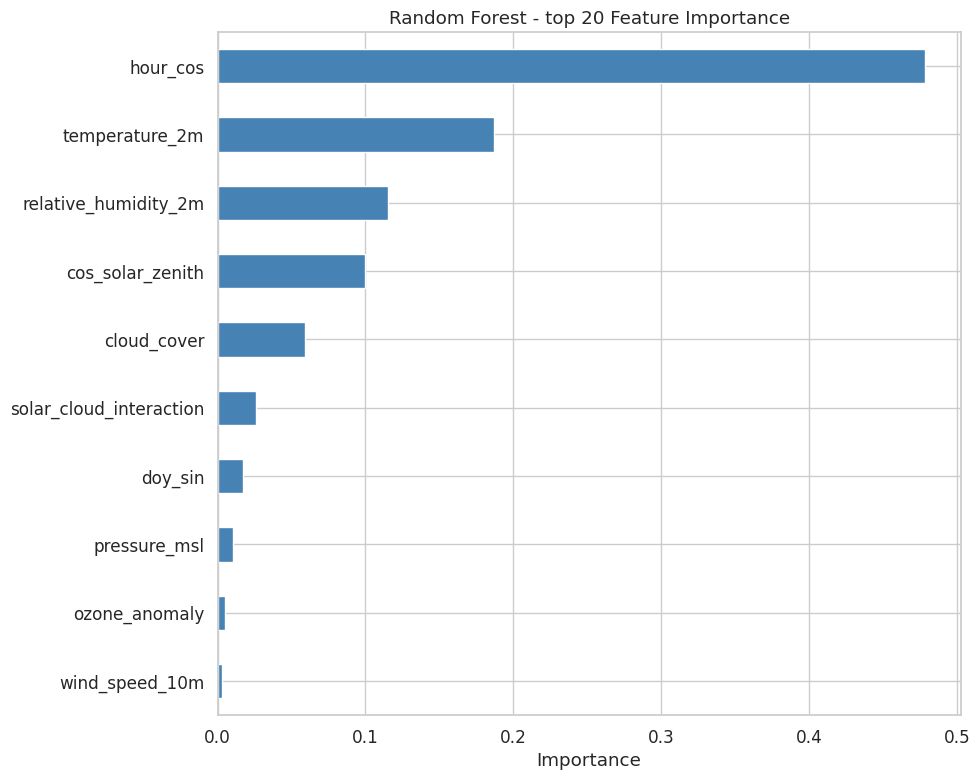

In [10]:
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
imp.head(20).sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_title('Random Forest - top 20 Feature Importance')
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

# 5. XGBoost

In [11]:
from sklearn.model_selection import train_test_split
X_fit, X_tune, y_fit, y_tune = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, shuffle=False)

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=3.0,
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
    early_stopping_rounds=30
)

xgb_model.fit(
    X_fit, y_fit,
    eval_set=[(X_tune, y_tune)],
    verbose=50
)
print(f"Best iteration: {xgb_model.best_iteration}")

pred_xgb_train = xgb_model.predict(X_train)
pred_xgb_val = xgb_model.predict(X_val)
pred_xgb_test = xgb_model.predict(X_test)

evaluate("XGBoost", y_train, pred_xgb_train, 'train')
evaluate('XGBoost', y_val, pred_xgb_val, 'val')
evaluate('XGBoost', y_test, pred_xgb_test, 'test')

[0]	validation_0-rmse:1.69917


[50]	validation_0-rmse:0.55563


[100]	validation_0-rmse:0.52543


[150]	validation_0-rmse:0.51609


[200]	validation_0-rmse:0.50816


...

[450]	validation_0-rmse:0.48222


[499]	validation_0-rmse:0.47833


Best iteration: 499


XGBoost_train MAE: 0.2075 RMSE: 0.4621 R2: 0.9337189424350552 MAPE: 21.601234036061097 
XGBoost_val MAE: 0.3171 RMSE: 0.7096 R2: 0.8702086440729205 MAPE: 30.218805539501307 
XGBoost_test MAE: 0.2842 RMSE: 0.6372 R2: 0.8668851422951174 MAPE: 36.34871963613997 


(0.28415224127759325,
 np.float64(0.6371849428271666),
 0.8668851422951174,
 np.float64(36.34871963613997))

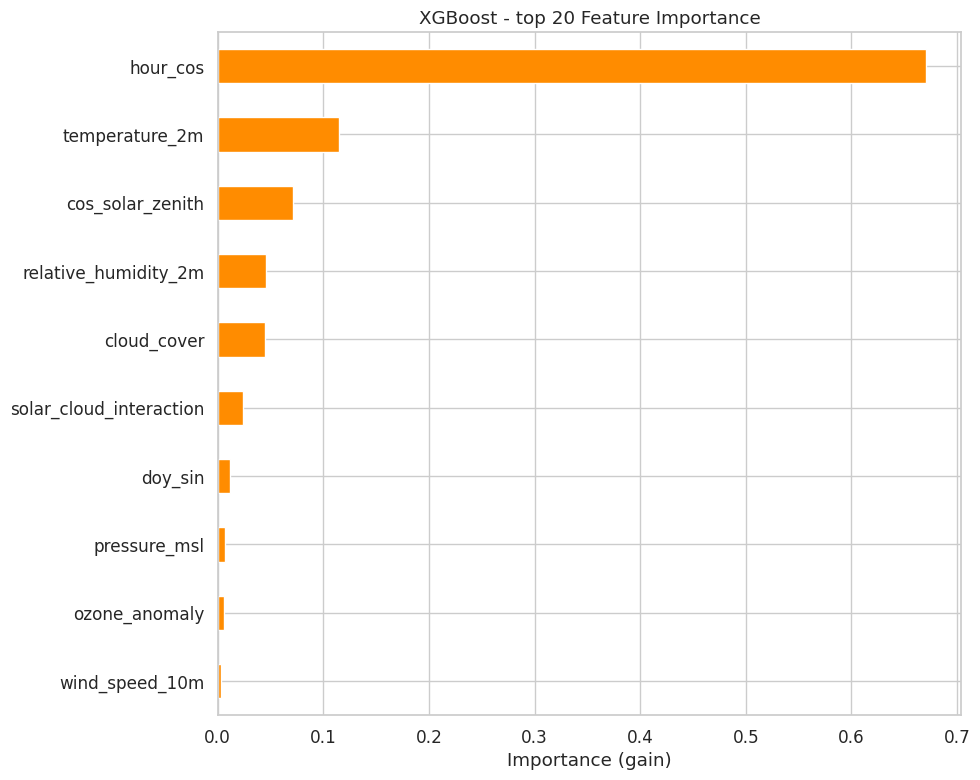

In [12]:
imp_xgb = pd.Series(
    xgb_model.feature_importances_,index=FEATURE_COLS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
imp_xgb.head(20).sort_values().plot.barh(ax=ax, color='darkorange')
ax.set_title('XGBoost - top 20 Feature Importance')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

# 6. LightGBM

In [13]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=30,
    reg_alpha=0.5,
    reg_lambda=3.0,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_fit, y_fit,
    eval_set=[(X_tune, y_tune)],
    callbacks=[
        lgb.early_stopping(30, verbose=True),
        lgb.log_evaluation(50)
    ]
)

print(f'Best iteration: {lgb_model.best_iteration_}')

pred_lgb_train = lgb_model.predict(X_train)
pred_lgb_val = lgb_model.predict(X_val)
pred_lgb_test = lgb_model.predict(X_test)
evaluate("LightGBM", y_train, pred_lgb_train, 'train')
evaluate('LightGBM', y_val, pred_lgb_val, 'val')
evaluate('LightGBM', y_test, pred_lgb_test, 'test')

Training until validation scores don't improve for 30 rounds


[50]	valid_0's l2: 0.309301


[100]	valid_0's l2: 0.27778


[150]	valid_0's l2: 0.267663


[200]	valid_0's l2: 0.260723


...

[400]	valid_0's l2: 0.238988


[450]	valid_0's l2: 0.235824


[500]	valid_0's l2: 0.232493
Did not meet early stopping. Best iteration is:
[500]	valid_0's l2: 0.232493
Best iteration: 500


LightGBM_train MAE: 0.2085 RMSE: 0.4730 R2: 0.9305570192536653 MAPE: 19.572643192067403 
LightGBM_val MAE: 0.3139 RMSE: 0.7112 R2: 0.8696228147462808 MAPE: 27.086918581543163 
LightGBM_test MAE: 0.2831 RMSE: 0.6389 R2: 0.8661582428045789 MAPE: 33.94128674874043 


(0.28308653006877127,
 np.float64(0.6389223102114273),
 0.8661582428045789,
 np.float64(33.94128674874043))

# 6.5 CatBoost

In [14]:
cb_model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=5,
    loss_function='RMSE',
    random_seed=SEED,
    verbose=0
)
cb_model.fit(
    X_train, y_train,
    eval_set=[(X_tune, y_tune)],
    early_stopping_rounds=30
)
print(f"Best iteration: {cb_model.get_best_iteration()}")
pred_cb_train = cb_model.predict(X_train)
pred_cb_val = cb_model.predict(X_val)
pred_cb_test = cb_model.predict(X_test)
evaluate('CatBoost', y_train, pred_cb_train, 'train')
evaluate('CatBoost', y_val, pred_cb_val, 'val')
evaluate('CatBoost', y_test, pred_cb_test, 'test')

Best iteration: 499
CatBoost_train MAE: 0.2240 RMSE: 0.5131 R2: 0.9182817585223579 MAPE: 19.99213890899535 
CatBoost_val MAE: 0.3097 RMSE: 0.7093 R2: 0.8703241044037366 MAPE: 25.645080930006348 
CatBoost_test MAE: 0.2798 RMSE: 0.6313 R2: 0.8693491592733015 MAPE: 33.69902227620397 


(0.27978833414204834,
 np.float64(0.6312601043409858),
 0.8693491592733015,
 np.float64(33.69902227620397))

# 7. LSTM (PyTorch)

In [15]:
SEQ_LEN = 48
BATCH = 256

print(f'Building sequences with look-back = {SEQ_LEN}h ...')

train_sorted = train.sort_values(['location_id', 'timestamp'])
val_sorted = val.sort_values(['location_id', 'timestamp'])
test_sorted = test.sort_values(['location_id', 'timestamp'])

seq_X_train, seq_y_train = [], []
seq_X_val, seq_y_val = [], []
seq_X_test, seq_y_test = [], []

for loc in df['location_id'].unique():
    for split_df, X_list, y_list in [
        (train_sorted, seq_X_train, seq_y_train),
        (val_sorted, seq_X_val, seq_y_val),
        (test_sorted, seq_X_test, seq_y_test),
    ]:
        mask = split_df['location_id'] == loc
        loc_X = scaler_X.transform(split_df.loc[mask, FEATURE_COLS].fillna(fill_values).values)
        loc_y = split_df.loc[mask, TARGET].values
        for i in range(SEQ_LEN - 1, len(loc_X)):
            X_list.append(loc_X[i - SEQ_LEN + 1:i + 1])
            y_list.append(loc_y[i])

seq_X_train = np.array(seq_X_train)
seq_y_train = np.array(seq_y_train)
seq_X_val = np.array(seq_X_val)
seq_y_val = np.array(seq_y_val)
seq_X_test = np.array(seq_X_test)
seq_y_test = np.array(seq_y_test)

print(f'Train sequences: {seq_X_train.shape}')
print(f'Val Sequences: {seq_X_val.shape}')
print(f'Test Sequences: {seq_X_test.shape}')

train_ds = TensorDataset(torch.tensor(seq_X_train, dtype=torch.float32),
                         torch.tensor(seq_y_train, dtype=torch.float32))
val_ds = TensorDataset(torch.tensor(seq_X_val, dtype=torch.float32),
                       torch.tensor(seq_y_val, dtype=torch.float32))
test_ds = TensorDataset(torch.tensor(seq_X_test, dtype=torch.float32),
                        torch.tensor(seq_y_test, dtype=torch.float32))

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=True)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH, shuffle=False)

Building sequences with look-back = 48h ...


Train sequences: (270505, 48, 10)
Val Sequences: (58301, 48, 10)
Test Sequences: (57058, 48, 10)


In [16]:
class UVIndexLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_layers=3, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 32),
            nn.GELU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)

N_FEATURES = seq_X_train.shape[-1]
model = UVIndexLSTM(N_FEATURES, hidden_dim=256, num_layers=3, dropout=0.3).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
criterion = nn.HuberLoss(delta=1.0)

print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

UVIndexLSTM(
  (lstm): LSTM(10, 256, num_layers=3, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=32, bias=True)
    (4): GELU(approximate='none')
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)
Parameters: 1,364,161


Epoch 1/80, train=0.1700 val=0.1446 lr: 2.93e-04 patience=0/20


Epoch 5/80, train=0.1016 val=0.1473 lr: 1.50e-04 patience=2/20


Epoch 10/80, train=0.0957 val=0.1436 lr: 3.00e-04 patience=1/20


Epoch 15/80, train=0.0915 val=0.1473 lr: 2.56e-04 patience=6/20


Epoch 20/80, train=0.0729 val=0.1670 lr: 1.50e-04 patience=11/20


Epoch 25/80, train=0.0582 val=0.1740 lr: 4.39e-05 patience=16/20


Early stopping at epoch 29


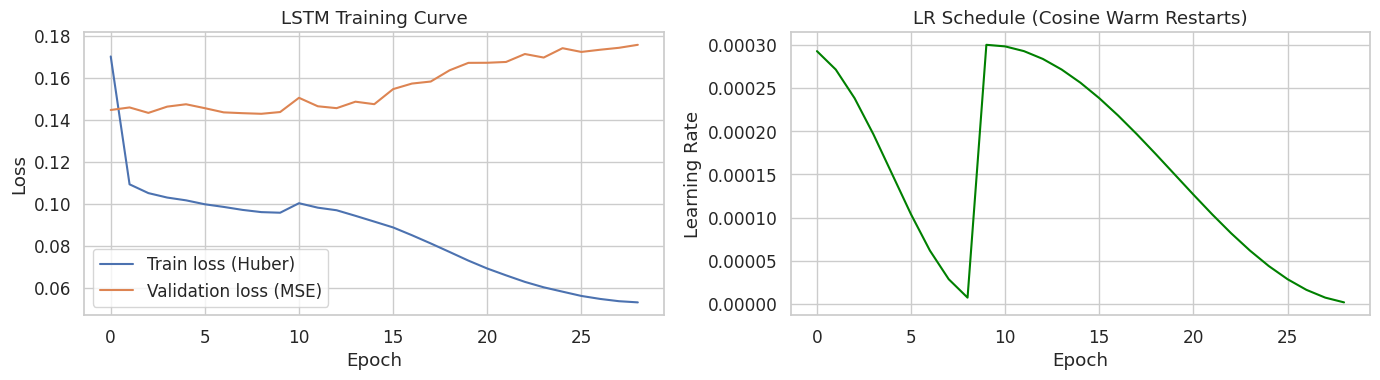

In [17]:
from pathlib import Path

Path('../../models/legacy').mkdir(exist_ok=True)

EPOCHS = 80
best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 20
history = {'train_loss': [], 'val_loss': [], 'lr': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for X_batch, y_batch in train_dl:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())

    scheduler.step(epoch)

    model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_dl:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            pred = model(X_batch)
            val_losses.append(criterion(pred, y_batch).item())

    avg_train = np.mean(train_losses)
    avg_val = np.mean(val_losses)
    lr_now = optimizer.param_groups[0]['lr']
    history['train_loss'].append(avg_train)
    history['val_loss'].append(avg_val)

    history['lr'].append(lr_now)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), '../../models/legacy/lstm_bst.pt')
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch}/{EPOCHS}, train={avg_train:.4f} val={avg_val:.4f} lr: {lr_now:.2e} patience={patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history['train_loss'], label='Train loss (Huber)')
ax1.plot(history['val_loss'], label='Validation loss (MSE)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('LSTM Training Curve')
ax1.legend()

ax2.plot(history['lr'], color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Learning Rate')
ax2.set_title('LR Schedule (Cosine Warm Restarts)')
plt.tight_layout()
plt.show()

In [18]:
try:
    state_dict = torch.load('../../models/legacy/lstm_bst.pt', weights_only=True)
except TypeError:
    # Older PyTorch versions don't support `weights_only=`.
    state_dict = torch.load('../../models/legacy/lstm_bst.pt', map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()

def lstm_predict(dl):
    preds = []
    with torch.no_grad():
        for X_batch, _ in dl:
            preds.append(model(X_batch.to(DEVICE)).cpu().numpy())
    return np.concatenate(preds)

train_eval_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=False, drop_last=False)

pred_lstm_train = lstm_predict(train_eval_dl)
pred_lstm_val = lstm_predict(val_dl)
pred_lstm_test = lstm_predict(test_dl)
evaluate('LSTM', seq_y_train, pred_lstm_train, 'train')
evaluate('LSTM', seq_y_val, pred_lstm_val, 'val')
evaluate('LSTM', seq_y_test, pred_lstm_test, 'test')

LSTM_train MAE: 0.1949 RMSE: 0.4972 R2: 0.9232502480217709 MAPE: 10.002034339039154 
LSTM_val MAE: 0.2647 RMSE: 0.6413 R2: 0.8943771039559925 MAPE: 12.034612244107077 
LSTM_test MAE: 0.2496 RMSE: 0.6025 R2: 0.881475760102671 MAPE: 20.752213762268127 


(0.24962472374037462,
 np.float64(0.6025384382253051),
 0.881475760102671,
 np.float64(20.752213762268127))

# 7.2 GRU (PyTorch)

In [19]:
class UVIndexGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)

gru_model = UVIndexGRU(N_FEATURES, hidden_dim=128, num_layers=2, dropout=0.2).to(DEVICE)
optimizer_gru = torch.optim.AdamW(gru_model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_gru = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_gru, T_0=10, T_mult=2)

GRU_EPOCHS = 80
best_val_loss_gru = float('inf')
patience_counter = 0
gru_history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, GRU_EPOCHS + 1):
    gru_model.train()
    train_losses = []
    for X_batch, y_batch in train_dl:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        pred = gru_model(X_batch)
        loss = criterion(pred, y_batch)
        optimizer_gru.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(gru_model.parameters(), 1.0)
        optimizer_gru.step()
        train_losses.append(loss.item())

    scheduler_gru.step(epoch)
        
    gru_model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_dl:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            pred = gru_model(X_batch)
            val_losses.append(criterion(pred, y_batch).item())

    avg_train = np.mean(train_losses)
    avg_val = np.mean(val_losses)
    gru_history['train_loss'].append(avg_train)
    gru_history['val_loss'].append(avg_val)

    if epoch % 10 == 0 or epoch == 1:
        print(f'GRU Epoch: {epoch}/{GRU_EPOCHS}, train={avg_train:.4f}, val={avg_val:.4f} patience={patience_counter}/{PATIENCE}')

    if avg_val < best_val_loss_gru:
        best_val_loss_gru = avg_val
        patience_counter = 0
        torch.save(gru_model.state_dict(), '../../models/legacy/gru_bst.pt')
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        break

state_dict = torch.load('../../models/legacy/gru_bst.pt', map_location=DEVICE)
gru_model.load_state_dict(state_dict)
gru_model.eval()

def gru_predict(dl):
    preds = []
    with torch.no_grad():
        for X_batch, _ in dl:
            preds.append(gru_model(X_batch.to(DEVICE)).cpu().numpy())
    return np.concatenate(preds)

train_eval_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=False, drop_last=False)


pred_gru_train = gru_predict(train_eval_dl)
pred_gru_val = gru_predict(val_dl)
pred_gru_test = gru_predict(test_dl)
evaluate('GRU', seq_y_train, pred_gru_train, 'train')
evaluate('GRU', seq_y_val, pred_gru_val, 'val')
evaluate('GRU', seq_y_test, pred_gru_test, 'test')

GRU Epoch: 1/80, train=0.1846, val=0.1460 patience=0/20


GRU Epoch: 10/80, train=0.1066, val=0.1414 patience=4/20


GRU Epoch: 20/80, train=0.1014, val=0.1525 patience=14/20


GRU_train MAE: 0.2006 RMSE: 0.5036 R2: 0.9212800525630471 MAPE: 11.150739257696026 
GRU_val MAE: 0.2673 RMSE: 0.6318 R2: 0.8974732209841966 MAPE: 13.085924614326084 
GRU_test MAE: 0.2576 RMSE: 0.6046 R2: 0.8806455507370685 MAPE: 21.49468153778883 


(0.25755346518832156,
 np.float64(0.6046450120883754),
 0.8806455507370685,
 np.float64(21.49468153778883))

# 7.3 BiLSTM (PyTorch)

In [20]:
class UVIndexBiLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout, bidirectional=True
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        out, _ = self.bilstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)

bilstm_model = UVIndexBiLSTM(N_FEATURES, hidden_dim=64, num_layers=2, dropout=0.2).to(DEVICE)
optimizer_bi = torch.optim.AdamW(bilstm_model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_bi = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_bi, T_0=10, T_mult=2)

BI_EPOCHS = 80
best_val_loss_bi = float('inf')
patience_counter = 0
bi_history = {'train_loss': [], 'val_loss': []}


for epoch in range(1, BI_EPOCHS + 1):
    bilstm_model.train()
    train_losses = []
    for X_batch, y_batch in train_dl:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        pred = bilstm_model(X_batch)
        loss = criterion(pred, y_batch)
        optimizer_bi.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(bilstm_model.parameters(), 1.0)
        optimizer_bi.step()
        train_losses.append(loss.item())

    scheduler_bi.step(epoch)
        
    bilstm_model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_dl:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            pred = bilstm_model(X_batch)
            val_losses.append(criterion(pred, y_batch).item())

    avg_train = np.mean(train_losses)
    avg_val = np.mean(val_losses)
    bi_history['train_loss'].append(avg_train)
    bi_history['val_loss'].append(avg_val)

    if epoch % 10 == 0 or epoch == 1:
        print(f'BiLSTM Epoch {epoch}/{BI_EPOCHS}, train={avg_train:.4f}, val={avg_val:.4f}, patience={patience_counter}/{PATIENCE}')

    if avg_val < best_val_loss_bi:
        best_val_loss_bi = avg_val
        patience_counter = 0
        torch.save(bilstm_model.state_dict(), '../../models/legacy/bilstm_bst.pt')
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        break

state_dict = torch.load('../../models/legacy/bilstm_bst.pt', map_location=DEVICE)
bilstm_model.load_state_dict(state_dict)
bilstm_model.eval()

def bilstm_predict(dl):
    preds = []
    with torch.no_grad():
        for X_batch, _ in dl:
            preds.append(bilstm_model(X_batch.to(DEVICE)).cpu().numpy())
    return np.concatenate(preds)

train_eval_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=False, drop_last=False)

pred_bilstm_train = bilstm_predict(train_eval_dl)
pred_bilstm_val = bilstm_predict(val_dl)
pred_bilstm_test = bilstm_predict(test_dl)
evaluate('BiLSTM', seq_y_train, pred_bilstm_train, 'train')
evaluate('BiLSTM', seq_y_val, pred_bilstm_val, 'val')
evaluate('BiLSTM', seq_y_test, pred_bilstm_test, 'test')

BiLSTM Epoch 1/80, train=0.1728, val=0.1573, patience=0/20


BiLSTM Epoch 10/80, train=0.1050, val=0.1439, patience=0/20


BiLSTM Epoch 20/80, train=0.1010, val=0.1488, patience=8/20


BiLSTM Epoch 30/80, train=0.0972, val=0.1486, patience=18/20


BiLSTM_train MAE: 0.2009 RMSE: 0.5041 R2: 0.9211126075418061 MAPE: 13.386868629814867 
BiLSTM_val MAE: 0.2680 RMSE: 0.6334 R2: 0.89693783797351 MAPE: 17.854102188869497 
BiLSTM_test MAE: 0.2652 RMSE: 0.6207 R2: 0.8742422421671633 MAPE: 29.615923401852655 


(0.265210251480998,
 np.float64(0.6206525739454376),
 0.8742422421671633,
 np.float64(29.615923401852655))

# 8. Model Comparison

,,MAE,RMSE,R2,MAPE
Model,Split,,,,
LSTM,test,0.2496,0.6025,0.8815,20.7522
GRU,test,0.2576,0.6046,0.8806,21.4947
RandomForest,test,0.2683,0.6171,0.8751,28.9827
BiLSTM,test,0.2652,0.6207,0.8742,29.6159
CatBoost,test,0.2798,0.6313,0.8693,33.6990
XGBoost,test,0.2842,0.6372,0.8669,36.3487
LightGBM,test,0.2831,0.6389,0.8662,33.9413
DecisionTree,test,0.2875,0.6976,0.8404,22.0448
LinearRegression,test,0.6121,0.8798,0.7462,264.0295


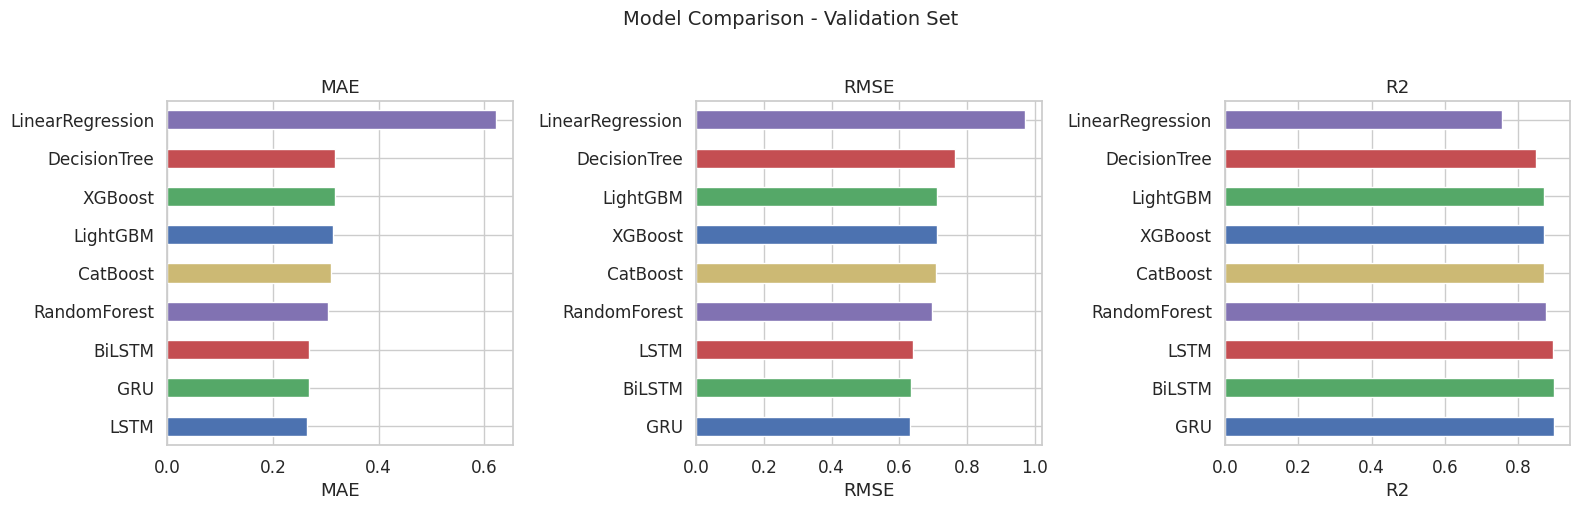

In [21]:
res_df = pd.DataFrame(results).T
res_df.index = pd.MultiIndex.from_tuples(
    [(k.rsplit('_', 1)[0], k.rsplit('_', 1)[1]) for k in results.keys()],
    names=['Model', 'Split']
)
display(res_df.round(4).sort_values(['Split', 'RMSE']))

val_results = {k.replace('_val', ''): v for k, v in results.items() if '_val' in k}
comp_df = pd.DataFrame(val_results).T

fix, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, metric in enumerate(['MAE', 'RMSE', 'R2']):
    comp_df[metric].sort_values(ascending=(metric != 'R2')).plot.barh(
        ax=axes[i], color=['#4c72b0', '#55a868', '#c44e52', '#8172b2', '#ccb974']
    )
    axes[i].set_title(metric)
    axes[i].set_xlabel(metric)
plt.suptitle('Model Comparison - Validation Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

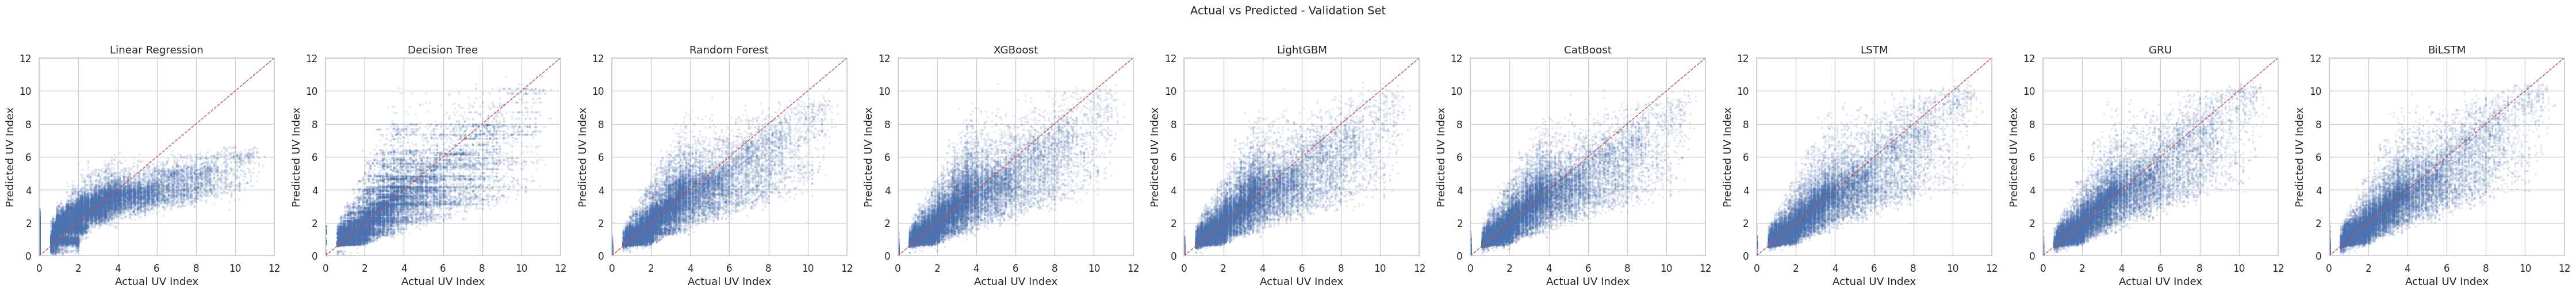

In [22]:
all_val_models = [
    ('Linear Regression', pred_lr_val, y_val),
    ('Decision Tree', pred_dt_val, y_val),
    ('Random Forest', pred_rf_val, y_val),
    ('XGBoost', pred_xgb_val, y_val),
    ('LightGBM', pred_lgb_val, y_val),
    ('CatBoost', pred_cb_val, y_val),
    ('LSTM', pred_lstm_val, seq_y_val),
    ('GRU', pred_gru_val, seq_y_val),
    ('BiLSTM', pred_bilstm_val, seq_y_val),
]
n_models = len(all_val_models)
fix, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
for ax, (name, pred, y_true_used) in zip(axes, all_val_models):
    plot_predictions(y_true_used, pred, name, ax=ax)
plt.suptitle('Actual vs Predicted - Validation Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Best model on val set: GRU


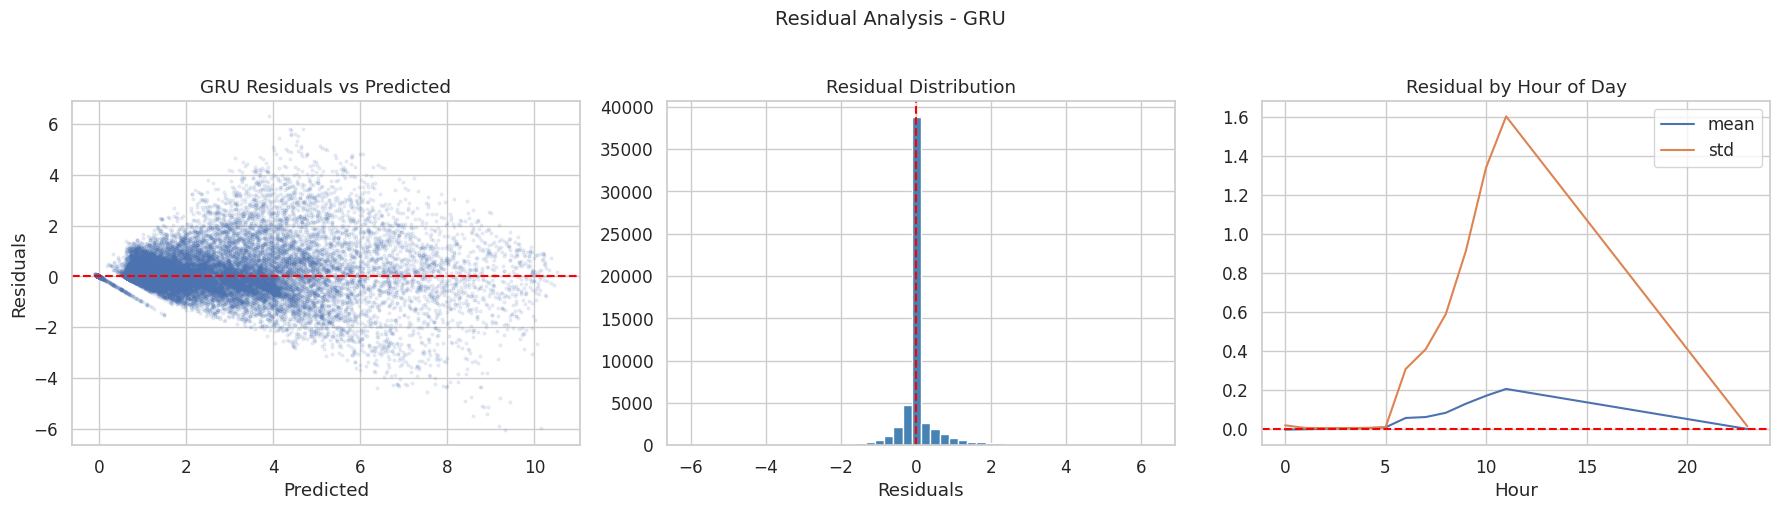

In [23]:
# Define lookup maps for all models (tabular + sequential)
# Tabular models use y_val, sequential models use seq_y_val (shorter due to sliding window)
TABULAR_MODELS = {
    'LinearRegression': (pred_lr_val,     y_val),
    'DecisionTree':     (pred_dt_val,     y_val),
    'RandomForest':     (pred_rf_val,     y_val),
    'XGBoost':          (pred_xgb_val,    y_val),
    'LightGBM':         (pred_lgb_val,    y_val),
    'CatBoost':         (pred_cb_val,     y_val),
}
SEQUENTIAL_MODELS = {
    'LSTM':             (pred_lstm_val,   seq_y_val),
    'GRU':              (pred_gru_val,    seq_y_val),
    'BiLSTM':           (pred_bilstm_val, seq_y_val),
}
ALL_VAL_MODELS = {**TABULAR_MODELS, **SEQUENTIAL_MODELS}

# Find best model across ALL models (tabular + sequential)
best_model_name = min(
    [(name, v['RMSE']) for name, v in {
        k.replace('_val', ''): results[k]
        for k in results if '_val' in k
    }.items() if name in ALL_VAL_MODELS],
    key=lambda x: x[1]
)[0]

best_preds, best_y_true = ALL_VAL_MODELS[best_model_name]
residuals = best_y_true - best_preds

print(f"Best model on val set: {best_model_name}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(best_preds, residuals, alpha=0.1, s=4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'{best_model_name} Residuals vs Predicted')

axes[1].hist(residuals, bins=50, edgecolor='white', color='steelblue')
axes[1].set_xlabel('Residuals')
axes[1].set_title('Residual Distribution')
axes[1].axvline(0, color='red', linestyle='--')

# For residual-by-hour: use val dataframe aligned to the predictions
# Sequential models are missing first SEQ_LEN rows per location → align via index
if best_model_name in SEQUENTIAL_MODELS:
    # seq_y_val was built from val_sorted; use the hours from those rows
    val_sorted_local = val.sort_values(['location_id', 'timestamp'])
    hour_arr = []
    for loc in df['location_id'].unique():
        loc_hours = val_sorted_local.loc[val_sorted_local['location_id'] == loc, 'hour'].values
        if len(loc_hours) > SEQ_LEN - 1:
            hour_arr.extend(loc_hours[SEQ_LEN - 1:].tolist())
    res_by_hour = pd.DataFrame({'hour': hour_arr[:len(residuals)], 'residual': residuals})
else:
    res_by_hour = pd.DataFrame({'hour': val['hour'].values, 'residual': residuals})

res_by_hour.groupby('hour')['residual'].agg(['mean', 'std']).plot(ax=axes[2])
axes[2].set_title('Residual by Hour of Day')
axes[2].set_xlabel('Hour')
axes[2].axhline(0, color='red', linestyle='--')

plt.suptitle(f'Residual Analysis - {best_model_name}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# 9. Test Set - final evaluation

FINAL TEST SET RESULTS


,MAE,RMSE,R2,MAPE
LSTM,0.2496,0.6025,0.8815,20.7522
GRU,0.2576,0.6046,0.8806,21.4947
RandomForest,0.2683,0.6171,0.8751,28.9827
BiLSTM,0.2652,0.6207,0.8742,29.6159
CatBoost,0.2798,0.6313,0.8693,33.6990
XGBoost,0.2842,0.6372,0.8669,36.3487
LightGBM,0.2831,0.6389,0.8662,33.9413
DecisionTree,0.2875,0.6976,0.8404,22.0448
LinearRegression,0.6121,0.8798,0.7462,264.0295


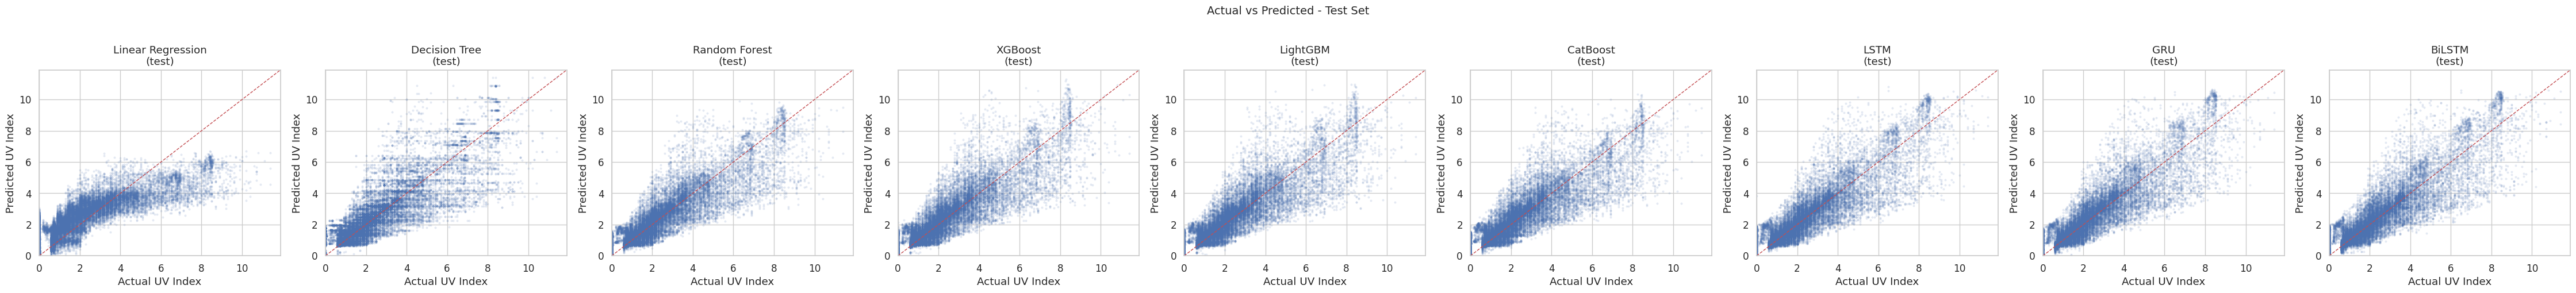

In [24]:
print('=' * 60)
print('FINAL TEST SET RESULTS')
print('=' * 60)

test_results = {k.replace('_test', ''): v for k, v in results.items() if '_test' in k}
test_res_df = pd.DataFrame(test_results).T.sort_values('RMSE')
display(test_res_df.round(4))

all_test_models = [
    ('Linear Regression', pred_lr_test, y_test),
    ('Decision Tree', pred_dt_test, y_test),
    ('Random Forest', pred_rf_test, y_test),
    ('XGBoost', pred_xgb_test, y_test),
    ('LightGBM', pred_lgb_test, y_test),
    ('CatBoost', pred_cb_test, y_test),
    ('LSTM', pred_lstm_test, seq_y_test),
    ('GRU', pred_gru_test, seq_y_test),
    ('BiLSTM', pred_bilstm_test, seq_y_test),
]
n_models = len(all_test_models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
for ax, (name, pred, y_true_used) in zip(axes, all_test_models):
    plot_predictions(y_true_used, pred, f'{name}\n(test)', ax=ax)
plt.suptitle('Actual vs Predicted - Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

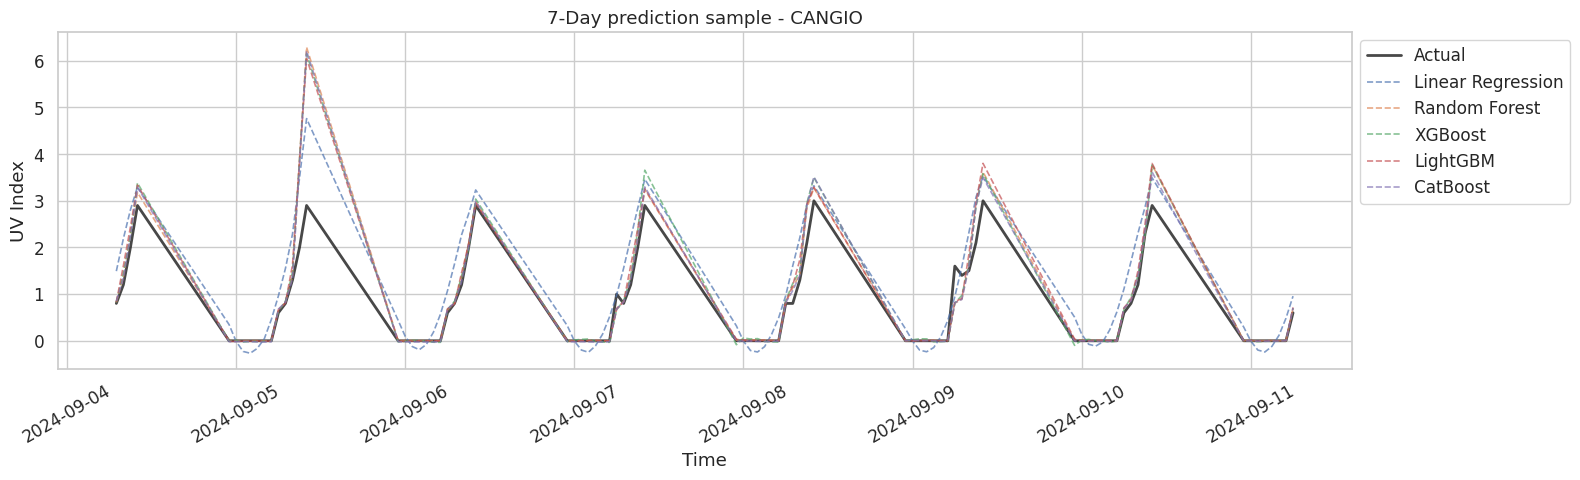

In [25]:
sample_loc = test['location_id'].unique()[0]
sample = test[test['location_id'] == sample_loc].head(7 * 12)
sample_X_nan = sample[FEATURE_COLS].values
sample_X_filled = sample[FEATURE_COLS].fillna(fill_values).values
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(sample['timestamp'].values, sample[TARGET].values, 'k-', linewidth=2, label='Actual', alpha=0.8)

model_preds = [
    ('Linear Regression', lr.predict(scaler_X.transform(sample_X_filled))),
    ('Random Forest', rf.predict(sample_X_nan)),
    ('XGBoost', xgb_model.predict(sample_X_nan)),
    ('LightGBM', lgb_model.predict(sample_X_nan)),
    ('CatBoost', cb_model.predict(sample_X_nan)),
]
for name, pred in model_preds:
    ax.plot(sample['timestamp'].values, pred, '--', linewidth=1.2, alpha=0.7, label=name)

ax.set_xlabel('Time')
ax.set_ylabel('UV Index')
ax.set_title(f'7-Day prediction sample - {sample_loc.upper()}')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Per-month test error breakdown:


MAE                                                              \
model   CatBoost DecisionTree LightGBM LinearRegression RandomForest XGBoost   
month                                                                          
2024-09   0.1382       0.1449   0.1451           0.4290       0.1349  0.1454   
2024-10   0.2126       0.2174   0.2106           0.4819       0.2070  0.2093   
2024-11   0.2509       0.2444   0.2587           0.5885       0.2435  0.2576   
2024-12   0.2069       0.1745   0.2073           0.6991       0.2023  0.2013   
2025-01   0.2312       0.2127   0.2263           0.6342       0.2202  0.2168   
2025-02   0.2905       0.3042   0.2936           0.6834       0.2908  0.2937   
2025-03   0.4442       0.4739   0.4456           0.6924       0.4300  0.4497   
2025-04   0.3695       0.4024   0.3770           0.6429       0.3597  0.3906   
2025-05   0.3427       0.3790   0.3475           0.5612       0.3396  0.3476   
2025-06   0.2405       0.2465   0.2333           0.4946       0.2316  0.2439   
2025-07   0.3166       0.3275   0.3208           0.5823       0.3179  0.3286   
2025-08   0.2629       0.2441   0.2721           0.4946       0.2367  0.2710   
2025-09   0.1404       0.1603   0.1480           0.4261       0.1328  0.1492   
2025-10   0.2019       0.2019   0.1968           0.4661       0.1950  0.1989   
2025-11   0.1938       0.2045   0.1982           0.5417       0.1876  0.1984   
2025-12   0.2347       0.2260   0.2305           0.6444       0.2259  0.2280   
2026-01   0.2851       0.2517   0.2804           0.6718       0.2623  0.2833   
2026-02   0.3457       0.3542   0.3524           0.7440       0.3349  0.3555   
2026-03   0.4613       0.5117   0.4825           0.8932       0.4245  0.4762   
2026-04   0.4140       0.4523   0.4227           0.9908       0.3720  0.4229   

              R2                                                              \
model   CatBoost DecisionTree LightGBM LinearRegression RandomForest XGBoost   
month                                                                          
2024-09   0.9047       0.8829   0.9046           0.7739       0.9043  0.9062   
2024-10   0.8472       0.8186   0.8432           0.7529       0.8497  0.8533   
2024-11   0.8264       0.8260   0.8195           0.6438       0.8433  0.8288   
2024-12   0.7861       0.7787   0.7877           0.1340       0.8005  0.7915   
2025-01   0.8269       0.7843   0.8316           0.5180       0.8325  0.8352   
2025-02   0.8419       0.7763   0.8405           0.6590       0.8383  0.8407   
2025-03   0.8262       0.7759   0.8187           0.7737       0.8311  0.8221   
2025-04   0.8781       0.8418   0.8696           0.7850       0.8794  0.8608   
2025-05   0.8424       0.8043   0.8416           0.8023       0.8485  0.8448   
2025-06   0.8635       0.8419   0.8676           0.7749       0.8710  0.8593   
2025-07   0.8237       0.8069   0.8242           0.7467       0.8262  0.8215   
2025-08   0.8338       0.8227   0.8199           0.7706       0.8450  0.8181   
2025-09   0.8846       0.8581   0.8820           0.7695       0.8881  0.8837   
2025-10   0.8665       0.8449   0.8712           0.7814       0.8711  0.8712   
2025-11   0.8694       0.8336   0.8663           0.6490       0.8745  0.8705   
2025-12   0.8458       0.8221   0.8569           0.5550       0.8546  0.8543   
2026-01   0.8444       0.8321   0.8482           0.6577       0.8545  0.8467   
2026-02   0.8534       0.8125   0.8486           0.7134       0.8638  0.8506   
2026-03   0.9152       0.8844   0.9091           0.7931       0.9242  0.9138   
2026-04   0.9322       0.9073   0.9270           0.7703       0.9369  0.9291   

            RMSE                                                              
model   CatBoost DecisionTree LightGBM LinearRegression RandomForest XGBoost  
month                                                                         
2024-09   0.3723       0.4128   0.3726           0.5735       0.3732  0.3693  
2024-10   0.536

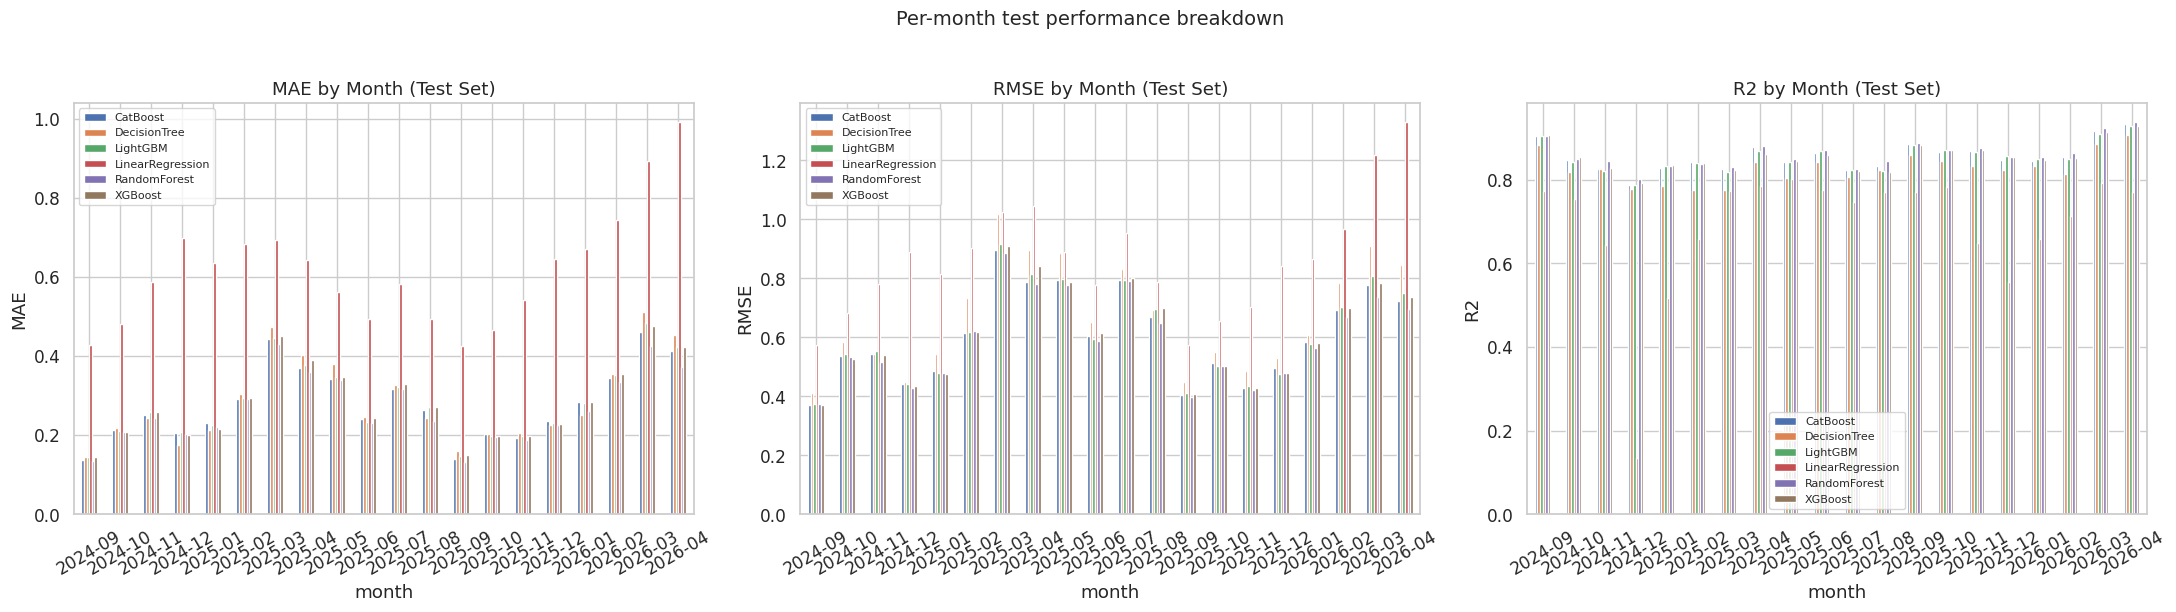

In [26]:
test_months = test['timestamp'].dt.to_period('M')

# Extended model set: all tabular models (sequential models need separate alignment)
best_test_pred = {
    'LinearRegression': pred_lr_test,
    'DecisionTree':     pred_dt_test,
    'RandomForest':     pred_rf_test,
    'XGBoost':          pred_xgb_test,
    'LightGBM':         pred_lgb_test,
    'CatBoost':         pred_cb_test,
}

rows = []
for name, pred in best_test_pred.items():
    for period in test_months.unique():
        mask = test_months == period
        y_true_m = y_test[mask.values]
        y_pred_m = pred[mask.values]
        if len(y_true_m) == 0:
            continue
        rows.append({
            'model': name,
            'month': str(period),
            'n': len(y_true_m),
            'MAE':  mean_absolute_error(y_true_m, y_pred_m),
            'RMSE': np.sqrt(mean_squared_error(y_true_m, y_pred_m)),
            'R2':   r2_score(y_true_m, y_pred_m),
        })

monthly_df = pd.DataFrame(rows)
print('Per-month test error breakdown:')
display(monthly_df.pivot_table(index='month', columns='model', values=['MAE', 'RMSE', 'R2']).round(4))

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for i, metric in enumerate(['MAE', 'RMSE', 'R2']):
    pivot = monthly_df.pivot(index='month', columns='model', values=metric)
    pivot.plot(kind='bar', ax=axes[i], rot=30)
    axes[i].set_title(f'{metric} by Month (Test Set)')
    axes[i].set_ylabel(metric)
    axes[i].legend(fontsize=8)

plt.suptitle('Per-month test performance breakdown', fontsize=14, y=1.02)
plt.subplots_adjust(wspace=0.3)
plt.tight_layout()
plt.show()


# 10. Save models

In [27]:
import joblib
MODEL_DIR = Path('../..') / 'models' /'legacy'
MODEL_DIR.mkdir(exist_ok=True, parents=True)

joblib.dump(rf, MODEL_DIR / 'rf_regressor.joblib')
joblib.dump(xgb_model, MODEL_DIR / 'xgb_regressor.joblib')
joblib.dump(lgb_model, MODEL_DIR / 'lgb_regressor.joblib')
joblib.dump(lr, MODEL_DIR / 'lr_regressor.joblib')
joblib.dump(cb_model, MODEL_DIR / 'cb_regressor.joblib')
joblib.dump(dt, MODEL_DIR / 'dt_regressor.joblib')
joblib.dump(scaler_X, MODEL_DIR / 'scaler_X.joblib')
joblib.dump(fill_values, MODEL_DIR / 'fill_values.joblib')
joblib.dump(FEATURE_COLS, MODEL_DIR / 'feature_cols.joblib')

test_res_df.round(4).to_csv(MODEL_DIR / 'regression_results.csv')
print(f'Model saved to {MODEL_DIR.resolve()}')
for f in sorted(MODEL_DIR.glob('*')):
    print(f' {f.name} ({f.stat().st_size / 1024:.0f} KB)')



Model saved to /home/dat-vu/Desktop/UV_analysis/models/legacy
 attn_lstm_hybrid.pt (3198 KB)
 bilstm_bst.pt (577 KB)
 cb_regressor.joblib (923 KB)
 cnn_lstm_hybrid.pt (3423 KB)
 dt_regressor.joblib (269 KB)
 feature_cols.joblib (0 KB)
 fill_values.joblib (2 KB)
 gru_bst.pt (633 KB)
 hybrid_l0_cat.joblib (56 KB)
 hybrid_l0_lgb.joblib (177 KB)
 hybrid_l0_rf.joblib (145438 KB)
 hybrid_l0_xgb.joblib (120 KB)
 hybrid_lgb_resid_cangio.joblib (81 KB)
 hybrid_lgb_resid_cuchi.joblib (79 KB)
 hybrid_lgb_resid_dalat.joblib (85 KB)
 hybrid_lgb_resid_hcm.joblib (81 KB)
 hybrid_lgb_resid_longhai.joblib (84 KB)
 hybrid_lgb_resid_nhabe.joblib (81 KB)
 hybrid_lgb_resid_thuduc.joblib (83 KB)
 hybrid_lgb_resid_vungtau.joblib (80 KB)
 hybrid_meta_ridge.joblib (0 KB)
 hybrid_prophet_cangio.joblib (1077 KB)
 hybrid_prophet_cuchi.joblib (1066 KB)
 hybrid_prophet_dalat.joblib (1036 KB)
 hybrid_prophet_hcm.joblib (1071 KB)
 hybrid_prophet_longhai.joblib (1078 KB)
 hybrid_prophet_nhabe.joblib (1068 KB)
 hybrid_

In [28]:
# Persistence baseline: predict UV = last known UV (uv_lag_1h)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np, pandas as pd
from pathlib import Path

DATA_DIR = Path('../../data/processed/features')
df_full = pd.read_csv(DATA_DIR / 'features_regression.csv', parse_dates=['timestamp'])

if 'uv_source' in df_full.columns:
    df_full = df_full[df_full['uv_source'].isin(['weatherbit', 'open_meteo']) & df_full['uv_index'].notna()].copy()

TARGET = 'uv_index'
min_date = df_full['timestamp'].min()
max_date = df_full['timestamp'].max()
total_days = (max_date - min_date).days

train_days = int(total_days * 0.70)
val_days = int(total_days * 0.15)
train_end = min_date + timedelta(days=train_days)
val_end = train_end + timedelta(days=val_days)

val_df  = df_full[(df_full['timestamp'] >=  train_end) & (df_full['timestamp'] < val_end)]
test_df = df_full[df_full['timestamp'] >= val_end]

def persistence_eval(split_df, split_name):
    # If standard lag features are missing from pipeline export to prevent leakage,
    # generate a local T-24h (same hour yesterday) baseline manually
    if 'uv_lag_24h' not in split_df.columns:
        df_sorted = split_df.sort_values(['location_id', 'timestamp']).copy()
        df_sorted['uv_lag_24h_fallback'] = df_sorted.groupby('location_id')['uv_index'].shift(24)
        split_df = df_sorted.copy()
        pred_col = 'uv_lag_24h_fallback'
    else:
        pred_col = 'uv_lag_24h'

    y_true = split_df[TARGET].fillna(0).values
    y_pred = split_df[pred_col].fillna(0).values
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[mask], y_pred[mask]
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  Persistence [{split_name}]  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.3f}')
    return {'model': 'Persistence (T-24h fallback)', 'split': split_name,
            'MAE': mae, 'RMSE': rmse, 'R2': r2}

print('=== Persistence Baseline ===')
p_val  = persistence_eval(val_df,  'val')
p_test = persistence_eval(test_df, 'test')
print('\n(Any model with RMSE < persistence RMSE adds real value beyond memory of past UV)')


=== Persistence Baseline ===
  Persistence [val]  MAE=1.2475  RMSE=2.2757  R2=-0.335
  Persistence [test]  MAE=0.9433  RMSE=1.8783  R2=-0.157

(Any model with RMSE < persistence RMSE adds real value beyond memory of past UV)


In [29]:
# ── Lag Feature Ablation Study (trên bộ 14 Filtered Features) ────────────────
# Câu hỏi: Trong 14 features lõi, UV lag features đóng góp bao nhiêu cho accuracy?
# Bài kiểm tra dùng:
#   WITH_LAG  = 14 core features + UV lag features
#   NO_LAG    = chỉ 14 core features (không có memory UV quá khứ)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from datetime import timedelta

DATA_DIR = Path('../../data/processed/features')
df = pd.read_csv(DATA_DIR / 'features_regression.csv', parse_dates=['timestamp'])

if 'uv_source' in df.columns:
    df = df[df['uv_source'].isin(['weatherbit', 'open_meteo']) & df['uv_index'].notna()].copy()

TARGET = 'uv_index'

# 14 core filtered features (không có lag)
FILTERED_14_COLS = [
    'cos_solar_zenith', 'hour_cos', 'doy_sin',
    'temperature_2m', 'relative_humidity_2m',
    'cloud_cover', 'cloud_cover_high', 'ozone_anomaly',
    'solar_cloud_interaction', 'pressure_msl',
    'precipitation', 'wind_speed_10m',
    'aerosol_optical_depth', 'pm2_5'
]
FILTERED_14_COLS = [c for c in FILTERED_14_COLS if c in df.columns]

# UV lag features (giá trị UV quá khứ — memory)
LAG_COLS = [c for c in df.columns if c.startswith('uv_lag') or c.startswith('uv_rolling')
            or c in ['uv_diff_1h', 'uv_max_today_so_far']]
# Loại leakage columns
LEAKAGE_COLS = ['shortwave_radiation', 'direct_radiation', 'diffuse_radiation',
                'clearness_index', 'solar_efficiency', 'radiation_ratio',
                'temp_radiation_ratio', 'uv_clear_sky_ratio']
LAG_COLS = [c for c in LAG_COLS if c not in LEAKAGE_COLS and c in df.columns]

WITH_LAG_FEATS = FILTERED_14_COLS + LAG_COLS   # 14 core + UV memory
NO_LAG_FEATS   = FILTERED_14_COLS               # chỉ 14 core (true model skill)

print(f"WITH_LAG features : {len(WITH_LAG_FEATS)} ({len(FILTERED_14_COLS)} core + {len(LAG_COLS)} lag)")
print(f"NO_LAG  features  : {len(NO_LAG_FEATS)} (chỉ core)")
print(f"UV lag cols       : {LAG_COLS}")

# Temporal split (giống pipeline chính)
min_date = df['timestamp'].min()
max_date = df['timestamp'].max()
total_days = (max_date - min_date).days
train_days = int(total_days * 0.70)
val_days   = int(total_days * 0.15)
train_end  = min_date + pd.Timedelta(days=train_days)
val_end    = train_end + pd.Timedelta(days=val_days)

train = df[(df['timestamp'] >= min_date) & (df['timestamp'] < train_end)]
val   = df[(df['timestamp'] >= train_end) & (df['timestamp'] < val_end)]

def run_ablation(feats, label):
    imp  = SimpleImputer(strategy='median')
    X_tr = imp.fit_transform(train[feats])
    X_v  = imp.transform(val[feats])
    sc   = StandardScaler().fit(X_tr)
    X_tr = sc.transform(X_tr)
    X_v  = sc.transform(X_v)
    y_tr = train[TARGET].fillna(0).values
    y_v  = val[TARGET].fillna(0).values

    res = {}
    for name, model in [
        ('RF',  RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
        ('XGB', xgb.XGBRegressor(n_estimators=100, max_depth=6, random_state=42, verbosity=0)),
    ]:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_v)
        rmse = np.sqrt(mean_squared_error(y_v, y_pred))
        r2   = r2_score(y_v, y_pred)
        res[name] = {'RMSE': rmse, 'R2': r2}
        print(f'  [{label}] {name}  RMSE={rmse:.4f}  R2={r2:.3f}')
    return res

print('\n=== WITH UV Lag Features (14 core + UV memory) ===')
with_lag = run_ablation(WITH_LAG_FEATS, 'WITH lag')

print('\n=== WITHOUT UV Lag Features (chỉ 14 core features) ===')
no_lag = run_ablation(NO_LAG_FEATS, 'NO lag')

print('\n=== RMSE Delta — đóng góp của UV Lag ===')
for name in ['RF', 'XGB']:
    delta = no_lag[name]['RMSE'] - with_lag[name]['RMSE']
    print(f'  {name}: RMSE(no-lag)={no_lag[name]["RMSE"]:.4f}  '
          f'RMSE(with-lag)={with_lag[name]["RMSE"]:.4f}  '
          f'Lag contribution: +{delta:.4f} RMSE improvement')
print()
print("Ghi chú: Nếu delta lớn → UV lag 1h mang nhiều thông tin.")
print("         Nếu delta nhỏ → 14 core features đã đủ độc lập với lag.")


WITH_LAG features : 10 (10 core + 0 lag)
NO_LAG  features  : 10 (chỉ core)
UV lag cols       : []

=== WITH UV Lag Features (14 core + UV memory) ===


  [WITH lag] RF  RMSE=0.7107  R2=0.870


  [WITH lag] XGB  RMSE=0.7487  R2=0.856

=== WITHOUT UV Lag Features (chỉ 14 core features) ===


  [NO lag] RF  RMSE=0.7107  R2=0.870


  [NO lag] XGB  RMSE=0.7487  R2=0.856

=== RMSE Delta — đóng góp của UV Lag ===
  RF: RMSE(no-lag)=0.7107  RMSE(with-lag)=0.7107  Lag contribution: +0.0000 RMSE improvement
  XGB: RMSE(no-lag)=0.7487  RMSE(with-lag)=0.7487  Lag contribution: +0.0000 RMSE improvement

Ghi chú: Nếu delta lớn → UV lag 1h mang nhiều thông tin.
         Nếu delta nhỏ → 14 core features đã đủ độc lập với lag.


In [30]:
## export resuult to CSV
import pandas as pd
from pathlib import Path
results_list = []
for key, metrics in results.items():
    if '_' in key:
        parts = key.rsplit('_', 1)
        if len(parts) == 2:
            model_name, split = parts
        else:
            model_name = key
            split = 'unknown'
    else:
        model_name = key
        split = metrics.get('split', 'unknown')

    results_list.append({
        'notebook': 'regression',
        'model': model_name,
        'split': split,
        'MAE': metrics.get('MAE'),
        'RMSE': metrics.get('RMSE'),
        'R2': metrics.get('R2'),
        'MAPE': metrics.get('MAPE')
    })

results_df = pd.DataFrame(results_list)

results_dir = Path('../../results')
results_dir.mkdir(exist_ok=True)
results_df.to_csv(results_dir / 'regression_results.csv', index=False)
print('SAVED REGRESSION RESULTS')

SAVED REGRESSION RESULTS


Using 10 filtered features for importance plot.


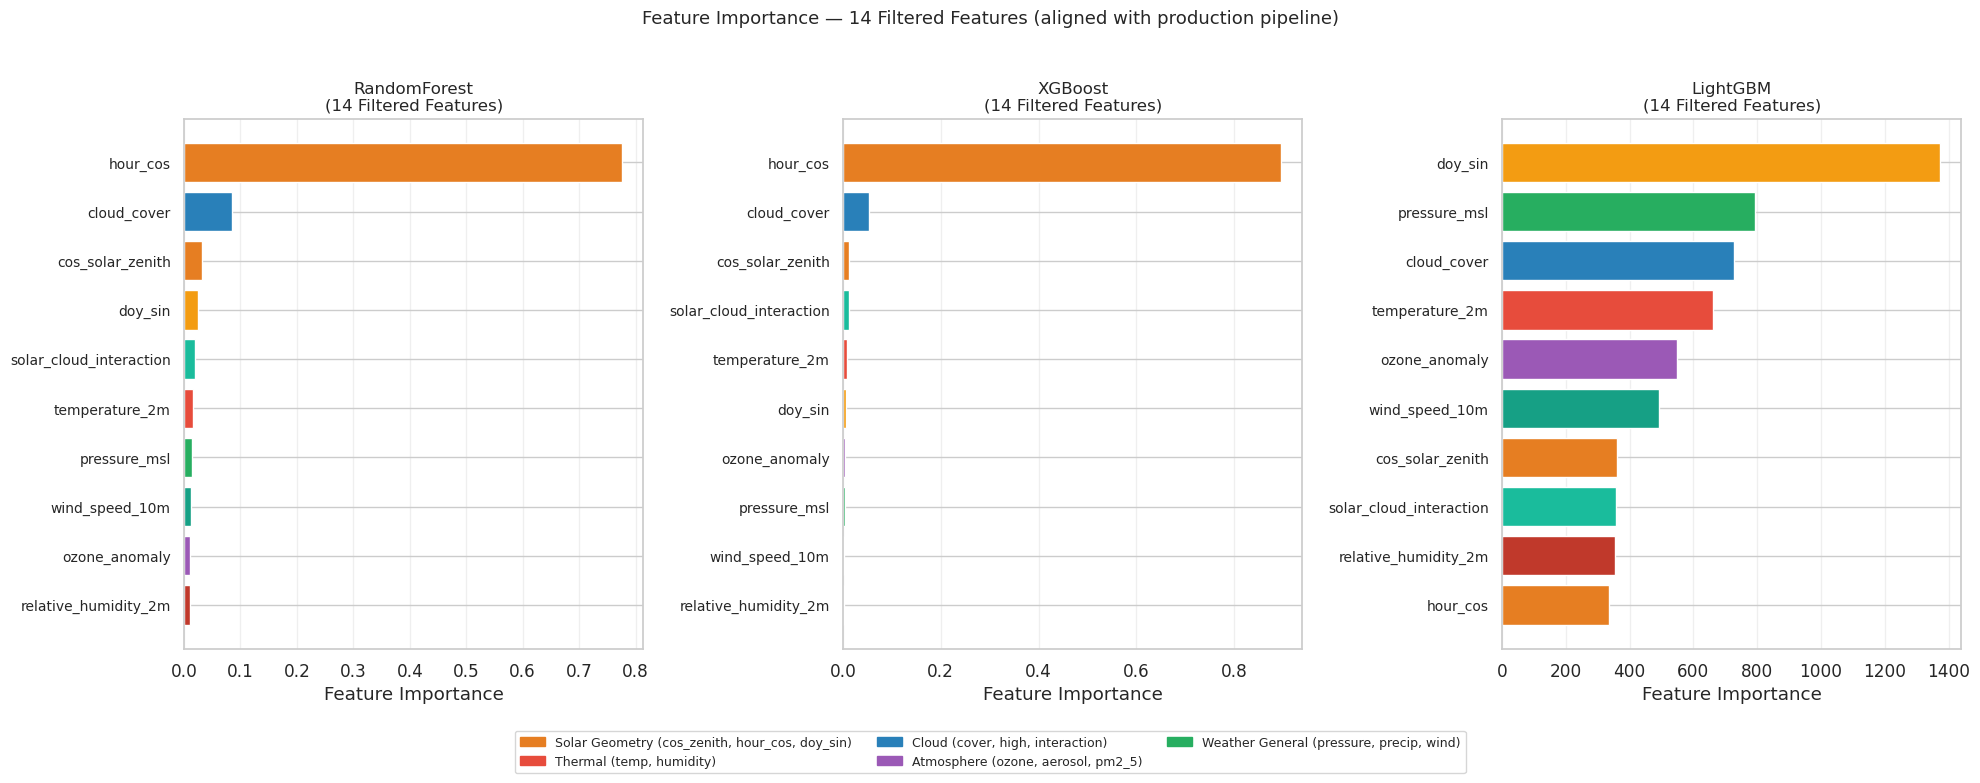

Nhận xét: Feature importance phản ánh tầm quan trọng thực sự của từng chiều thông tin vật lý.
Solar geometry và cloud interaction thường chiếm top, phù hợp với vật lý UV.


In [31]:
# ── Feature Importance Plot (14 Filtered Features) ────────────────────────────
# Phân tích tầm quan trọng của 14 features vật lý cốt lõi theo từng model.
# Mục tiêu: Xác định features nào đóng góp chính trong bộ 14 đã lọc.
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

DATA_DIR = Path('../../data/processed/features')
df = pd.read_csv(DATA_DIR / 'features_regression.csv', parse_dates=['timestamp'])
TARGET = 'uv_index'

# 14 filtered features (đồng nhất với toàn bộ pipeline)
FILTERED_14_COLS = [
    'cos_solar_zenith', 'hour_cos', 'doy_sin',
    'temperature_2m', 'relative_humidity_2m',
    'cloud_cover', 'cloud_cover_high', 'ozone_anomaly',
    'solar_cloud_interaction', 'pressure_msl',
    'precipitation', 'wind_speed_10m',
    'aerosol_optical_depth', 'pm2_5'
]
FILTERED_14_COLS = [c for c in FILTERED_14_COLS if c in df.columns]
print(f"Using {len(FILTERED_14_COLS)} filtered features for importance plot.")

# Filter real UV data only
if 'uv_source' in df.columns:
    df = df[df['uv_source'].isin(['weatherbit', 'open_meteo']) & df[TARGET].notna()].copy()

train = df[df['timestamp'].dt.year <= 2024]
imp  = SimpleImputer(strategy='median')
X_tr = imp.fit_transform(train[FILTERED_14_COLS])
y_tr = train[TARGET].fillna(0).values

models_fi = {
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':      xgb.XGBRegressor(n_estimators=200, max_depth=6, random_state=42, verbosity=0),
    'LightGBM':     lgb.LGBMRegressor(n_estimators=200, verbose=-1, random_state=42),
}

# Color coding by feature group
GROUP_COLORS = {
    'cos_solar_zenith':        '#e67e22',  # Orange = Solar geometry
    'hour_cos':                '#e67e22',
    'doy_sin':                 '#f39c12',
    'temperature_2m':          '#e74c3c',  # Red = Thermo
    'relative_humidity_2m':    '#c0392b',
    'cloud_cover':             '#2980b9',  # Blue = Cloud
    'cloud_cover_high':        '#3498db',
    'solar_cloud_interaction': '#1abc9c',  # Teal = Interaction
    'ozone_anomaly':           '#9b59b6',  # Purple = Atmosphere
    'aerosol_optical_depth':   '#8e44ad',
    'pm2_5':                   '#6c3483',
    'pressure_msl':            '#27ae60',  # Green = Weather general
    'precipitation':           '#2ecc71',
    'wind_speed_10m':          '#16a085',
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (name, model) in zip(axes, models_fi.items()):
    model.fit(X_tr, y_tr)
    imps = model.feature_importances_
    # Sort descending
    order = np.argsort(imps)  # ascending for barh
    cols_sorted = [FILTERED_14_COLS[i] for i in order]
    vals_sorted = imps[order]
    colors = [GROUP_COLORS.get(c, '#95a5a6') for c in cols_sorted]

    bars = ax.barh(range(len(cols_sorted)), vals_sorted, color=colors)
    ax.set_yticks(range(len(cols_sorted)))
    ax.set_yticklabels(cols_sorted, fontsize=10)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{name}\n(14 Filtered Features)', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(color='#e67e22', label='Solar Geometry (cos_zenith, hour_cos, doy_sin)'),
    Patch(color='#e74c3c', label='Thermal (temp, humidity)'),
    Patch(color='#2980b9', label='Cloud (cover, high, interaction)'),
    Patch(color='#9b59b6', label='Atmosphere (ozone, aerosol, pm2_5)'),
    Patch(color='#27ae60', label='Weather General (pressure, precip, wind)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Feature Importance — 14 Filtered Features (aligned with production pipeline)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print("Nhận xét: Feature importance phản ánh tầm quan trọng thực sự của từng chiều thông tin vật lý.")
print("Solar geometry và cloud interaction thường chiếm top, phù hợp với vật lý UV.")
